# Practice 1.1: Classical Neural Networks
MQIST 2025/26: Quantum Computing and Machine Learning
Alfredo Chavert Sancho

In [2]:
print("Hello World")

Hello World


## - Data Loading

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical
import keras
from keras import layers
from keras.datasets import fashion_mnist

In [ ]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## - Preprocessing

In [ ]:
print(f"Train images: {train_images.shape}")
print(f"Train labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}")
print(f"Test labels: {test_labels.shape}")

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


#### Data flattening

In [ ]:
train_images = train_images.reshape((60000, 28*28))
test_images = test_images.reshape((10000, 28*28))

#### Converting [0,255] integers to [0,1] floats

In [ ]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

#### One hot encoding

In [ ]:
train_labels = to_categorical(train_labels)
#test_labels = to_categorical(test_labels)

#### Validation data separation

In [ ]:
val_images = train_images[:10000]
val_labels = train_labels[:10000]
train_images = train_images[10000:]
train_labels = train_labels[10000:]

## - Neural Network Setup

#### Structural hyperparameters:
- Layers: 2
- Neurons per layer: 50
- Layer activation function: sigmoid
- Output activation function: softmax

In [ ]:
model = keras.Sequential(name='fashion_mnist')
model.add(layers.Input(shape=(28*28, )))
model.add(layers.Dense(50, name='hidden_1', activation='sigmoid')) # To change
model.add(layers.Dense(50, name='hidden_2', activation='sigmoid')) # To change
model.add(layers.Dense(10, name='output', activation='softmax'))

In [ ]:
model.summary()

Model: "fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,310 (165.27 KB)

 Trainable params: 42,310 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

#### Learning hyperparameters:
- Optimizer: adam
- Loss function: categorical_crossentropy
- Learning rate: 0.01
- Epoch: 20
- Batch size: 512

In [ ]:
learning_rate = 0.001
opt = keras.optimizers.Adam(learning_rate = learning_rate)
loss_function = "categorical_crossentropy"
model.compile(optimizer = opt, loss = loss_function, metrics = ["accuracy"])
epochs = 25
batch_size = 512

In [ ]:
history = model.fit(train_images,
                    train_labels,
                    epochs = epochs,
                    batch_size = batch_size,
                    validation_data = (val_images, val_labels))

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4001 - loss: 2.0466 - val_accuracy: 0.6543 - val_loss: 1.2981
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6638 - loss: 1.1588 - val_accuracy: 0.7148 - val_loss: 0.8823
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7317 - loss: 0.8240 - val_accuracy: 0.7735 - val_loss: 0.6993
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7851 - loss: 0.6621 - val_accuracy: 0.8057 - val_loss: 0.5890
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8163 - loss: 0.5599 - val_accuracy: 0.8248 - val_loss: 0.5234
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8320 - loss: 0.5004 - val_accuracy: 0.8368 - val_loss: 0.4793
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8448 - loss: 0.4588 - val_accuracy: 0.8430 - val_loss: 0.4517
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8506 - loss: 0.4303 - val_accuracy: 0.8509 - val_lo

In [ ]:
import matplotlib.pyplot as plt

def plot(axis, train, validation, title):
    # We create a list of epoch numbers from 1 to the length of the training set
    epochs = range(1, len(train) + 1)
    # Graph of the training data with a solid blue line
    axis.plot(epochs, train, 'b-o', label='Training ' + title)
    # Graph of the validation data with a red dashed line
    axis.plot(epochs, validation, 'r--o', label='Validation '+ title)
    # We set the title of the graph, the X and Y axis labels
    axis.set_title('Training and validation ' + title)
    axis.set_xlabel('Epochs')
    axis.set_ylabel(title)
    # We show the legend of the graph
    axis.legend()

def multiplot(history):
    fig, axes = plt.subplots(1, 2)
    fig.set_figwidth(11)
    plot(axes[0], history.history['loss'], history.history['val_loss'], 'loss')
    plot(axes[1], history.history['accuracy'], history.history['val_accuracy'], 'accuracy')

    # We show the graphs on screen
    plt.show()

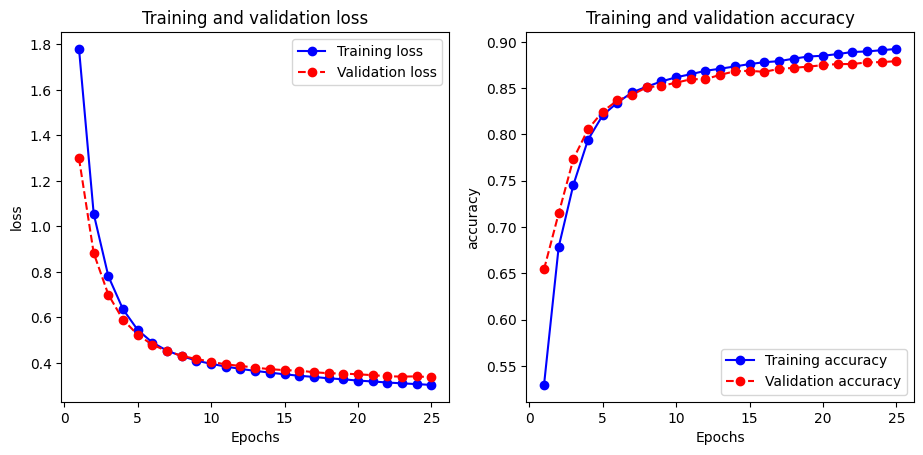

In [ ]:
history_dict = history.history
multiplot(history)

In [ ]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [ ]:
from sklearn.metrics import classification_report
# Evaluate the model
predicted_values = model.predict(test_images)
predicted_classes = np.argmax(predicted_values, axis =1)
# Classification report for precision, recall and f1-score
report = classification_report(test_labels, predicted_classes, target_names = ['T-shirt/top',
                                                                               'Trouser',
                                                                               'Pullover',
                                                                               'Dress',
                                                                               'Coat',
                                                                               'Sandal',
                                                                               'Shirt',
                                                                               'Sneaker',
                                                                               'Bag',
                                                                               'Ankle boot'])
# Print the evaluation metrics
print ("Classification Report:")
print (report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.81      0.82      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.75      0.80      0.77      1000
       Dress       0.84      0.89      0.87      1000
        Coat       0.79      0.76      0.78      1000
      Sandal       0.96      0.94      0.95      1000
       Shirt       0.70      0.66      0.68      1000
     Sneaker       0.92      0.94      0.93      1000
         Bag       0.96      0.97      0.96      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



## - Regularization

#### Early stopping

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', mode="min", patience=5) # Usar val_accuracy (max)

#### Dropout, batch normalization, weight regularization and initialization

In [ ]:
from keras import regularizers, initializers
dropout_per = 0.1 # Dropout percentage per dense layer
reg = regularizers.l2(0.01) # L2 regularizer
init = initializers.GlorotUniform() # GlorotUniform initializer

In [ ]:
model_reg = keras.Sequential(name='fashion_mnist')
model_reg.add(layers.Input(shape=(28*28, )))
model_reg.add(layers.Dense(50, kernel_regularizer = reg, name='hidden_1', activation='sigmoid', kernel_initializer = init))
model_reg.add(layers.Dropout(dropout_per)) # Dropout layer
model_reg.add(layers.BatchNormalization()) # Batch normalization layer
model_reg.add(layers.Dense(50, kernel_regularizer = reg, name='hidden_2',activation='sigmoid', kernel_initializer = init))
model_reg.add(layers.Dropout(dropout_per)) # Dropout layer
model_reg.add(layers.BatchNormalization()) # Batch normalization layer
model_reg.add(layers.Dense(10, name='output',  activation='softmax'))

In [ ]:
model_reg.summary()

Model: "fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,710 (166.84 KB)

 Trainable params: 42,510 (166.05 KB)

 Non-trainable params: 200 (800.00 B)

In [ ]:
learning_rate = 0.001
opt_reg = keras.optimizers.Adam(learning_rate = learning_rate)
loss_function = "categorical_crossentropy"
epochs = 25
batch_size = 512
model_reg.compile(optimizer = opt_reg, loss = loss_function, metrics = ["accuracy"])
history_reg = model_reg.fit(train_images,
                    train_labels,
                    epochs = epochs,
                    batch_size = batch_size,
                    validation_data = (val_images, val_labels),
                    callbacks=[early_stopping])

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5050 - loss: 2.6965 - val_accuracy: 0.4305 - val_loss: 2.5125
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7369 - loss: 1.2984 - val_accuracy: 0.7191 - val_loss: 1.6542
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7596 - loss: 0.9912 - val_accuracy: 0.7962 - val_loss: 1.0921
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7650 - loss: 0.8906 - val_accuracy: 0.8155 - val_loss: 0.8472
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7704 - loss: 0.8400 - val_accuracy: 0.8120 - val_loss: 0.7433
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7709 - loss: 0.8124 - val_accuracy: 0.8190 - val_loss: 0.6934
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7738 - loss: 0.7947 - val_accuracy: 0.8075 - val_loss: 0.6947
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7755 - loss: 0.7783 - val_accuracy: 0.8264 - v

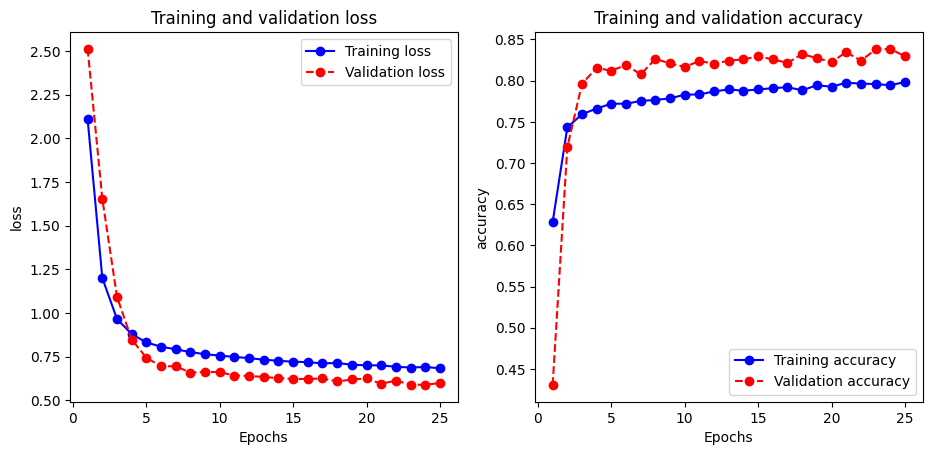

In [ ]:
history_dict_reg = history_reg.history
multiplot(history_reg)

In [ ]:
# Evaluate the model
predicted_values_reg = model_reg.predict(test_images)
predicted_classes_reg = np.argmax(predicted_values_reg, axis =1)
# Classification report for precision, recall and f1-score
report_reg = classification_report(test_labels, predicted_classes_reg, target_names = ['T-shirt/top',
                                                                               'Trouser',
                                                                               'Pullover',
                                                                               'Dress',
                                                                               'Coat',
                                                                               'Sandal',
                                                                               'Shirt',
                                                                               'Sneaker',
                                                                               'Bag',
                                                                               'Ankle boot'])
# Print the evaluation metrics
print ("Classification Report:")
print (report_reg)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.78      0.79      0.78      1000
     Trouser       0.99      0.93      0.96      1000
    Pullover       0.76      0.65      0.70      1000
       Dress       0.78      0.88      0.83      1000
        Coat       0.62      0.87      0.73      1000
      Sandal       0.95      0.86      0.90      1000
       Shirt       0.63      0.42      0.51      1000
     Sneaker       0.89      0.89      0.89      1000
         Bag       0.95      0.93      0.94      1000
  Ankle boot       0.87      0.96      0.91      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



## - Results

## - Conclusion